## This is the working jupyter notebook for the Quant Bio Lab Project. 

#### First Steps
1) Input Image
2) Apply Gaussian Filter for blurring
3) Apply Thresholding via CV2 Library
    - Do I need to normalize the stack? 
4) Apply Contour finding via CV2 Library
5) Apply to the whole image stack
6) Pray. 

In [3]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def gaussian_kernal(size,std):
    kernel = np.fromfunction(
        lambda x,y: np.divide(1,2*np.pi* std**2) * 
        np.exp(
            -((x-(size-1)/2)**2 + (y-(size-1)/2)**2) / (2* std**2)
               ),
        (size,size)
    )
    return np.array(kernel/np.sum(kernel))



In [4]:
kernel = gaussian_kernal(3,np.sqrt(3))
low_thresh: int = 13
high_thresh: int = 50

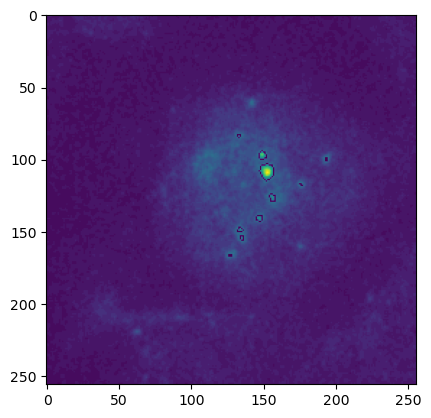

In [5]:
input = r"/Users/cmdb/Quant_Bio_Project/Quant-Bio-Project/segmentation_test.tif" 
img = cv.imread(input, cv.IMREAD_GRAYSCALE)
image = cv.filter2D(img,-1,kernel)
ret,thresh = cv.threshold(image,low_thresh,high_thresh,cv.THRESH_BINARY)
contours,hierarchy = cv.findContours(thresh, 1, 2)
test = cv.drawContours(image, contours, -5, (0, 255, 0), 1) 
plt.imshow(test)
plt.show()


(array([[[126, 166]],

       [[126, 167]],

       [[128, 167]],

       [[128, 166]]], dtype=int32), array([[[134, 153]],

       [[134, 155]],

       [[135, 156]],

       [[136, 156]],

       [[136, 153]]], dtype=int32), array([[[133, 147]],

       [[133, 148]],

       [[132, 149]],

       [[132, 150]],

       [[135, 150]],

       [[136, 149]],

       [[134, 147]]], dtype=int32), array([[[146, 139]],

       [[145, 140]],

       [[145, 142]],

       [[146, 142]],

       [[147, 143]],

       [[148, 143]],

       [[149, 142]],

       [[149, 139]]], dtype=int32), array([[[155, 124]],

       [[154, 125]],

       [[154, 126]],

       [[155, 127]],

       [[155, 129]],

       [[158, 129]],

       [[158, 125]],

       [[157, 125]],

       [[156, 124]]], dtype=int32), array([[[175, 117]],

       [[176, 118]],

       [[177, 118]],

       [[176, 117]]], dtype=int32), array([[[152, 103]],

       [[151, 104]],

       [[149, 104]],

       [[148, 105]],

       [[148,

print(contours)